In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from mlxtend.plotting import plot_decision_regions

In [16]:
data = pd.read_csv('D:\Datascience\Zoo.csv')
data

#Renaming the column animal name to animal_name
data=data.rename({'animal name':'animal_name'},axis=1)
data.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [17]:
print(data.head())
print(data.columns)

  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   type  
0     1  
1     1  
2     4  
3     1  
4     1  
Index(['

C:\Users\rames\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


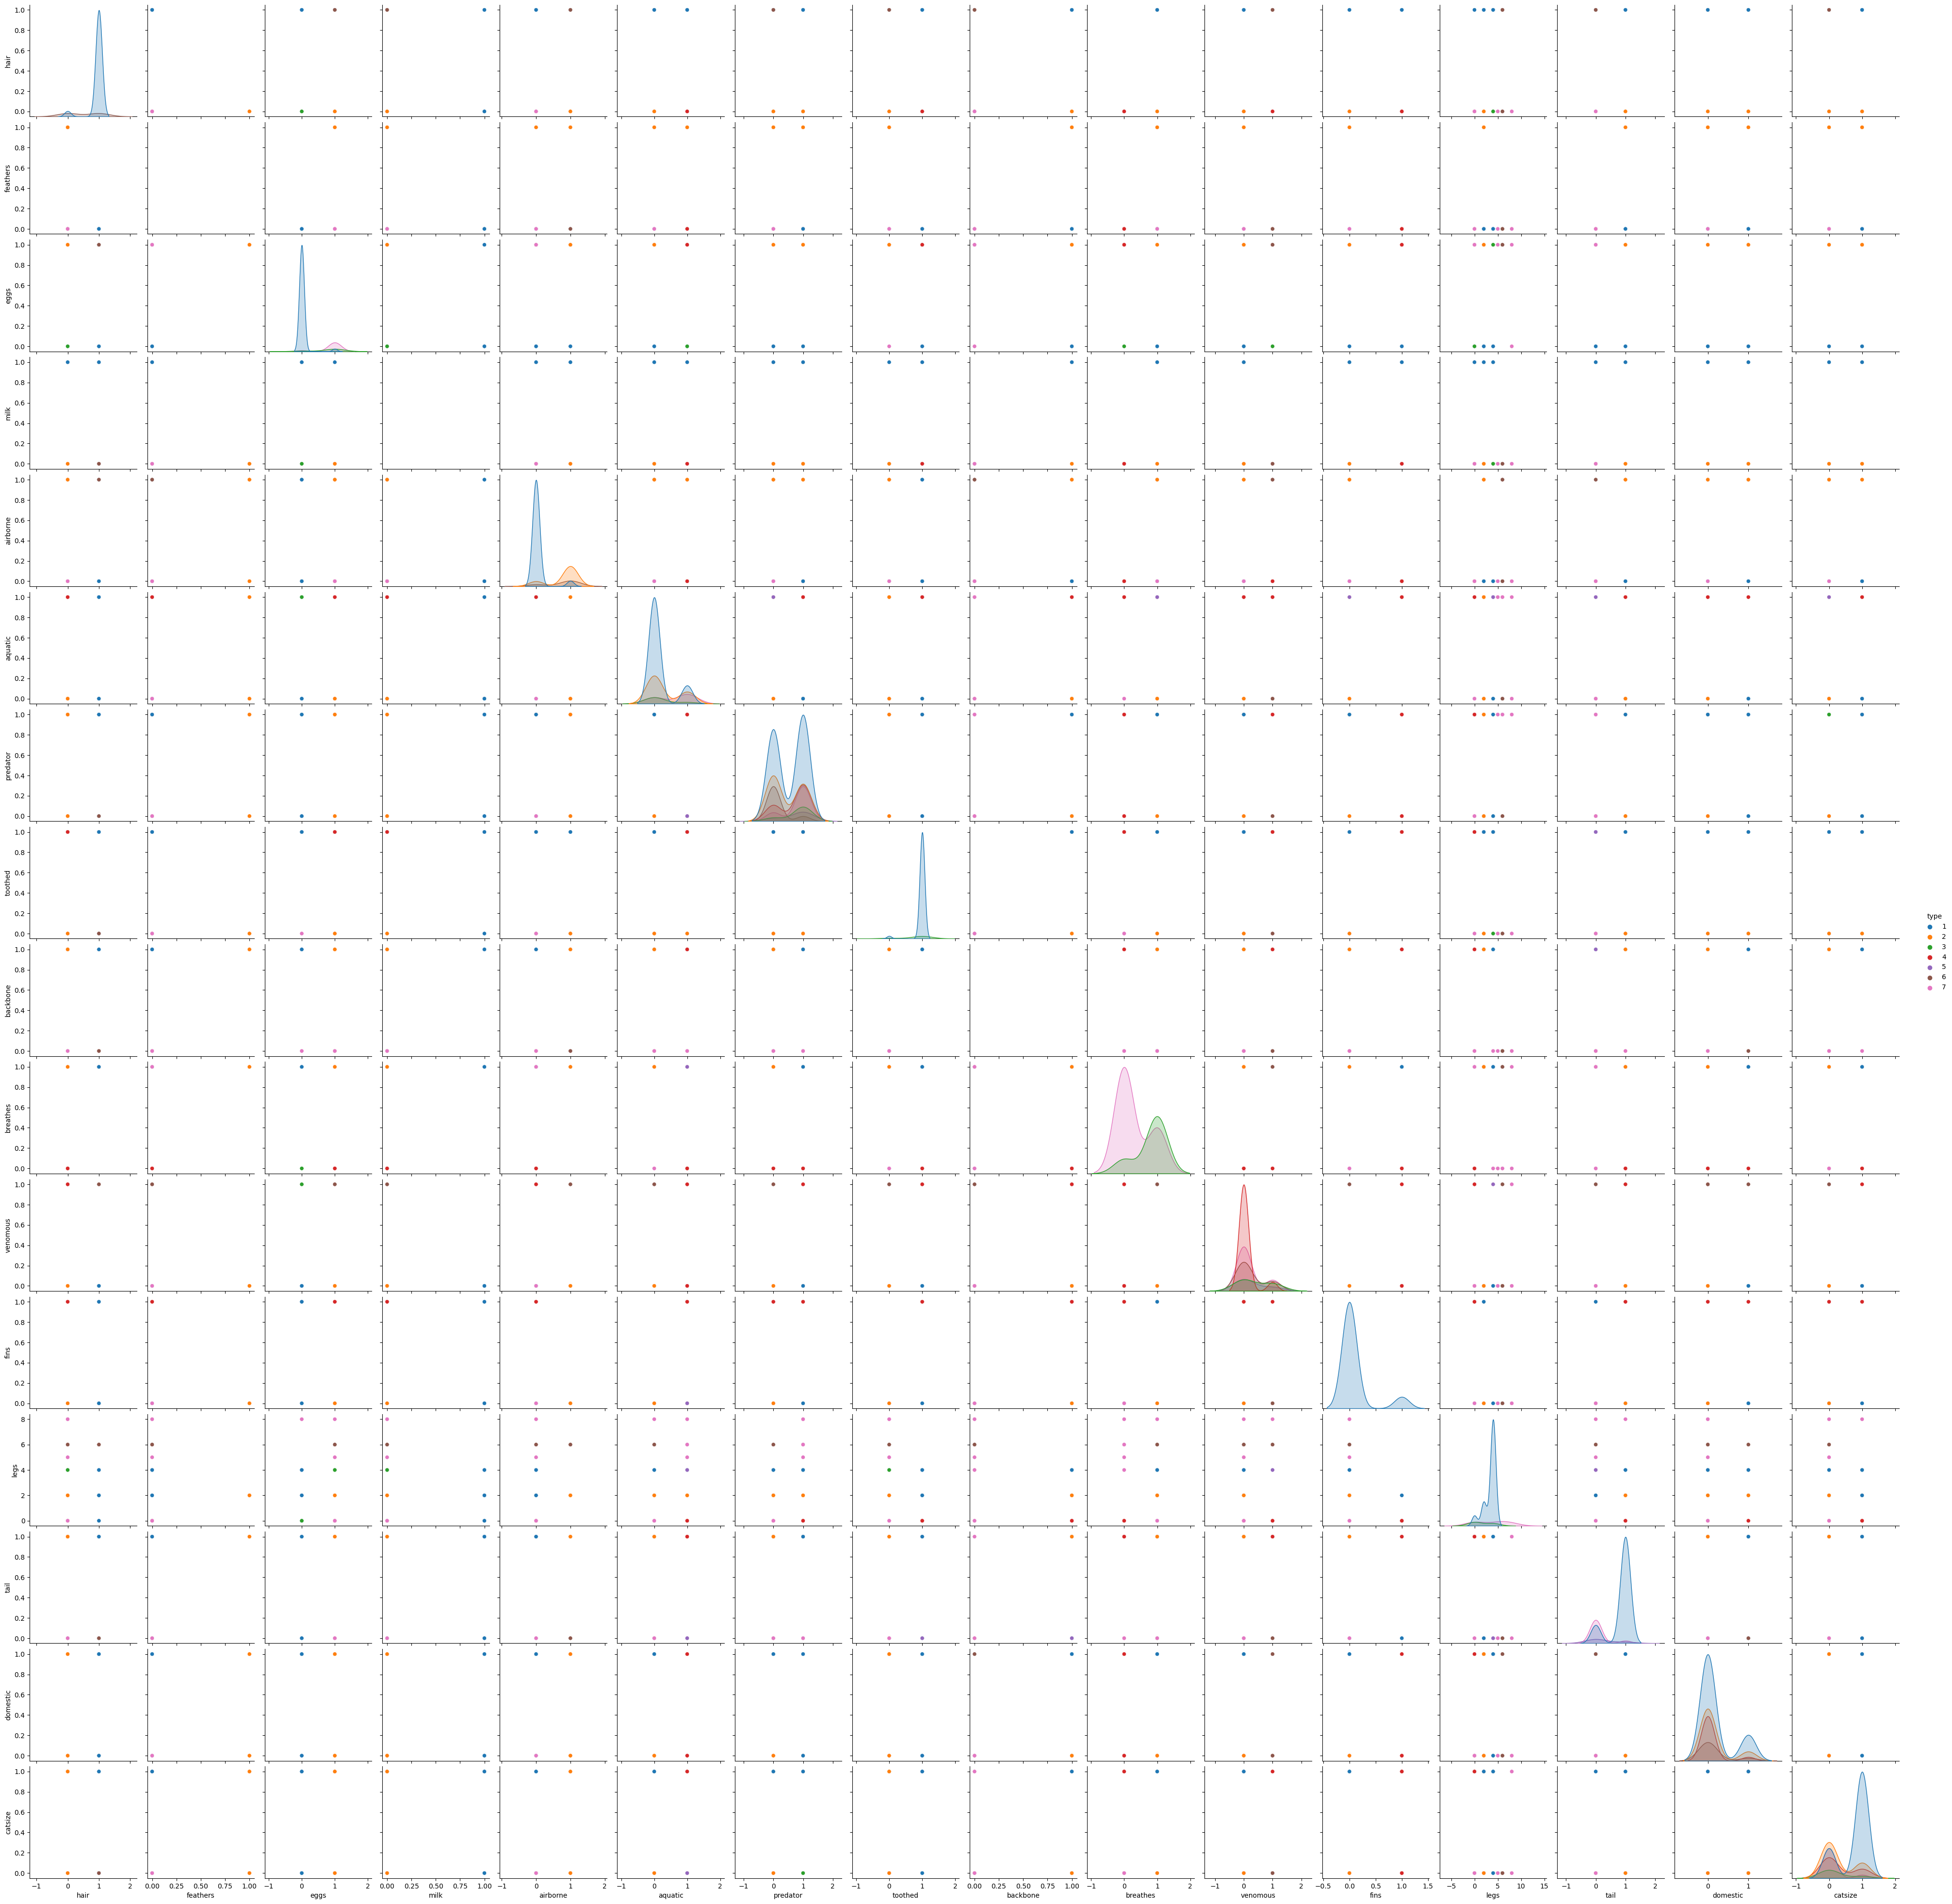

In [18]:
#ensuring 'type' column is categorical
data['type'] = data['type'].astype('category')

# Analyzing the data using visualization
# Plotting pairplot only for numerical features
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
sns.pairplot(data[numerical_cols + ['type']], hue='type')
plt.show()

In [19]:
print(data.isnull().sum())

animal_name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64


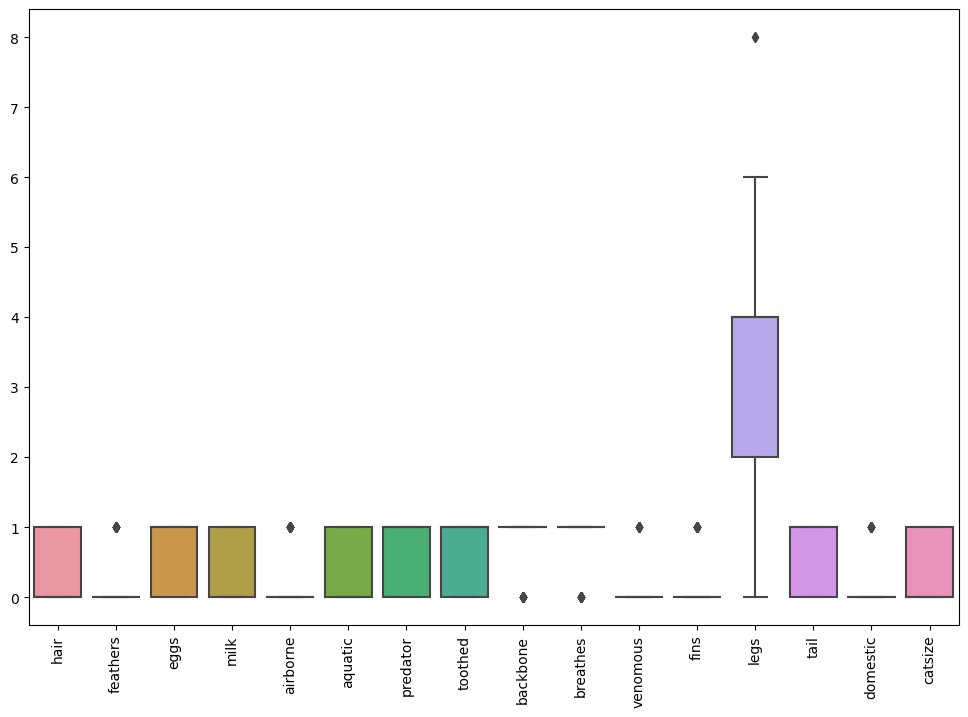

In [20]:
#no missing values, we can now check for outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=data.drop(columns=['type', 'animal_name']))
plt.xticks(rotation=90)
plt.show()

In [21]:
#Splitting the dataset into features and target
X = data.drop(columns=['type', 'animal_name'])  # Dropping 'animal_name' as it's not a feature
y = data['type']

In [22]:
#Standardising the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
#Splitting the dataset into training and testing sets (80% training and 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [24]:
#Implementing K-Nearest neighbours algorithm
k = 5  # Choosing k=5 as an example
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [25]:
#Predicting on the testing set
y_pred = knn.predict(X_test)

In [26]:
#Evaluating the classifier's performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9523809523809523
Precision: 0.7777777777777777
Recall: 0.8333333333333334
F1 Score: 0.7999999999999999

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



C:\Users\rames\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\rames\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\rames\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\rames\anaconda3\Lib\site-packages\sklearn\metrics\_classifi

C:\Users\rames\anaconda3\Lib\site-packages\mlxtend\plotting\decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


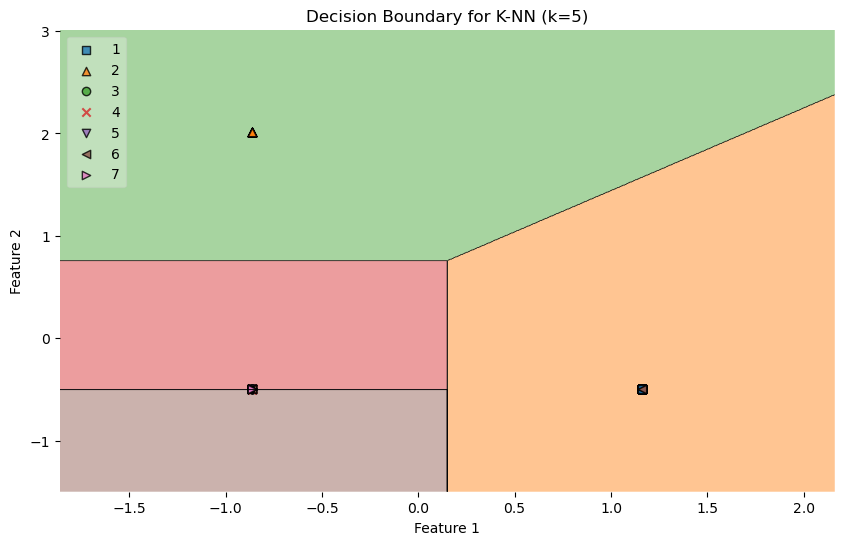

In [29]:
#Visualising the decision boundaries of the classifier
# Note: This step is often more useful for 2D data. We will use only two features for visualization purposes.
X_train_2d = X_train[:, :2]
X_test_2d = X_test[:, :2]

# Converting y_train to a NumPy array of integers
y_train_2d = y_train.astype(int).values

knn_2d = KNeighborsClassifier(n_neighbors=k)
knn_2d.fit(X_train_2d, y_train_2d)

plt.figure(figsize=(10, 6))
plot_decision_regions(X_train_2d, y_train_2d, clf=knn_2d, legend=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary for K-NN (k=5)')
plt.show()

In [ ]:
#Hyperparameters used in knn

#Number of Neighbors (k): It specifies the number of nearest neighbors to consider when making a classification or regression decision.
#A smaller k (e.g. 1) makes the model more sensitive to noise, while a larger k can smooth out predictions but may also overlook small patterns.

#Distance Metric : This determines how the distance between points is calculated.
#Common distance metrics include:
#Euclidean distance ('euclidean'): The straight-line distance between two points in Euclidean space.
#Manhattan distance ('manhattan'): The sum of the absolute differences of their Cartesian coordinates.
#Minkowski distance ('minkowski'): A generalization of both Euclidean and Manhattan distances.
#Hamming distance ('hamming'): Used for categorical variables where the distance between two vectors is the number of positions at which the corresponding elements are different.

#Weight Function : Determines how the contribution of each neighbor is weighted when making predictions.
#Options include:
#Uniform weights ('uniform'): All points in each neighborhood are weighted equally.
#Distance weights ('distance'): Closer neighbors have more influence than farther ones.

#Algorithm : Determines the algorithm used to compute the nearest neighbors.
#Options include:
#auto: Lets the algorithm decide the most appropriate method based on the input data.
#ball_tree: Uses BallTree data structure, efficient for high-dimensional data.
#kd_tree: Uses KDTree data structure, efficient for low-dimensional data.
#brute: Uses a brute-force search, which is suitable for small datasets.

#Leaf Size (for BallTree and KDTree) : Affects the speed of the construction and query of the tree, and the memory required to store it.
#The optimal leaf size depends on the nature of the problem.

#p (for Minkowski distance) : Determines the power parameter for the Minkowski metric.
#When p=1, it corresponds to Manhattan distance, and when p=2, it corresponds to Euclidean distance.
#Larger values of p give more weight to larger differences between feature values.

#Metric Parameters : Additional parameters for the distance metric. For instance, if using the Mahalanobis distance, you need to specify the covariance matrix.

In [ ]:
#from sklearn.neighbors import KNeighborsClassifier

# Example of setting hyperparameters for KNeighborsClassifier
#knn = KNeighborsClassifier(
#    n_neighbors=5,         # Number of neighbors
#    metric='minkowski',    # Distance metric
#    p=2,                   # Power parameter for Minkowski metric
#    weights='distance',    # Weight function
#    algorithm='auto',      # Algorithm to compute nearest neighbors
#    leaf_size=30           # Leaf size for BallTree and KDTree
#)

#knn.fit(X_train, y_train)
#y_pred = knn.predict(X_test)


In [ ]:
#Tuning hyperparameters techniques using Grid Search and Randomised Search with cross-validation to find optimal set of hyperparameters
#Using GridSearchCV

#from sklearn.model_selection import GridSearchCV

# Define the parameter grid
#param_grid = {
#    'n_neighbors': [3, 5, 7, 9],
#    'weights': ['uniform', 'distance'],
#    'metric': ['euclidean', 'manhattan', 'minkowski'],
#    'p': [1, 2]  # Only relevant if using 'minkowski' metric
#}

# Initialize KNN model
#knn = KNeighborsClassifier()

# Perform grid search
#grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
#grid_search.fit(X_train, y_train)

# Best parameters and score
#print("Best parameters:", grid_search.best_params_)
#print("Best cross-validation score:", grid_search.best_score_)

# Predict with the best model
#best_knn = grid_search.best_estimator_
#y_pred = best_knn.predict(X_test)

In [ ]:
#Distance metrics used in KNN

#Euclidean : It is the straight-line distance between two points in Euclidean space.
#knn_euclidean = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

#Manhattan : Sum of absolute differences of their cartesian coordinates.
#knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')

#Minkowski : It has a parameter p that allows for different distance metrics.
#knn_minkowski = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=3)

#Chebyshev : maximum absolute distance between the coordinates of a pair of points.
#knn_chebyshev = KNeighborsClassifier(n_neighbors=5, metric='chebyshev')

#Hamming : categorical variables where it measures the number of positions at which the corresponding elements are different.
#knn_hamming = KNeighborsClassifier(n_neighbors=5, metric='hamming')

#Cosine : Measures the cosine of the angle between two non-zero vectors in an inner product space.
#Useful when the magnitude of the vectors is not as important as their orientation.
#knn_cosine = KNeighborsClassifier(n_neighbors=5, metric='cosine')

#Mahalanobis : Takes into account the correlations of dataset and is scale-invariant.
#useful for identifying the outliers in multi-variate data.


#Fit and predict using the chosen distance metric
#knn_euclidean.fit(X_train, y_train)
#y_pred_euclidean = knn_euclidean.predict(X_test)

#same for other distance metrics

#clear points for distance metrics : 

#Euclidean and Manhattan: Generally used for continuous variables. Euclidean is more sensitive to outliers.
#Minkowski: Provides flexibility; useful if you want to experiment with different values of p.
#Chebyshev: Suitable for scenarios where the maximum difference in any dimension is the measure of distance.
#Hamming: Best for categorical data or binary features.
#Cosine: Effective when the orientation of the data matters more than the magnitude, such as in text classification or document similarity.
#Mahalanobis: Suitable for data with correlated features or when you want to consider the distribution of the data.